# Hashline report — charts

**Implementers:** [§2 Quick reference](hashline_hypothesis_report.md#2-quick-reference-for-implementers) in the MD report (fuzzy match → [`fuzzy_replace.py`](../src/harness/fuzzy_replace.py)).

Full narrative: [hashline_hypothesis_report.md](hashline_hypothesis_report.md)

Wrote figures to /Users/leshchenko/coding_projects/harness_test/docs/figures


,pass_rate,turns,tokens
label,,,
H1: docs fix,0.9,5.9,27383.8
H2: fuzzy replace,1.0,5.3,20115.1
H3: empty-hash,0.7,9.0,46785.4
OpenCrabs control,0.9,5.3,30696.5
str_replace only,0.9,4.9,8412.2


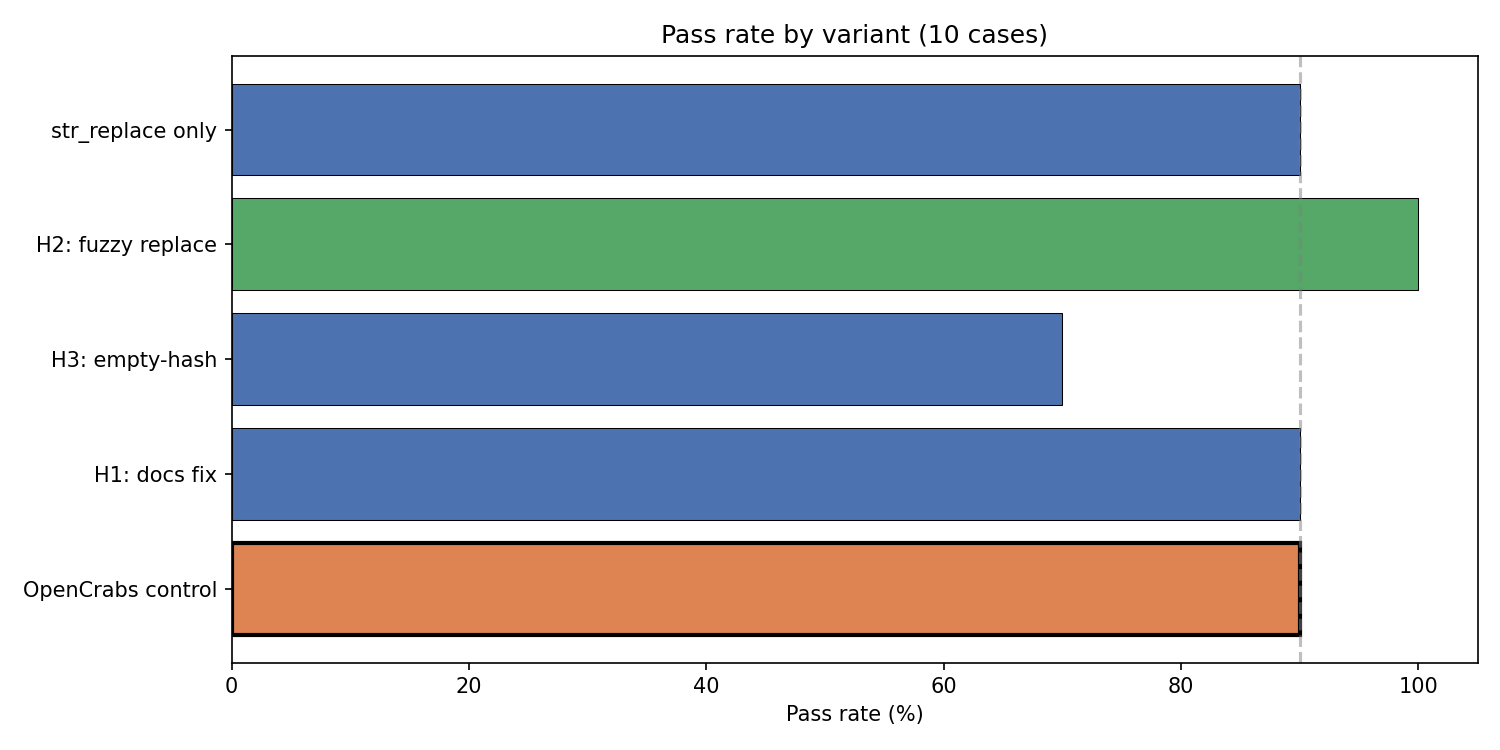

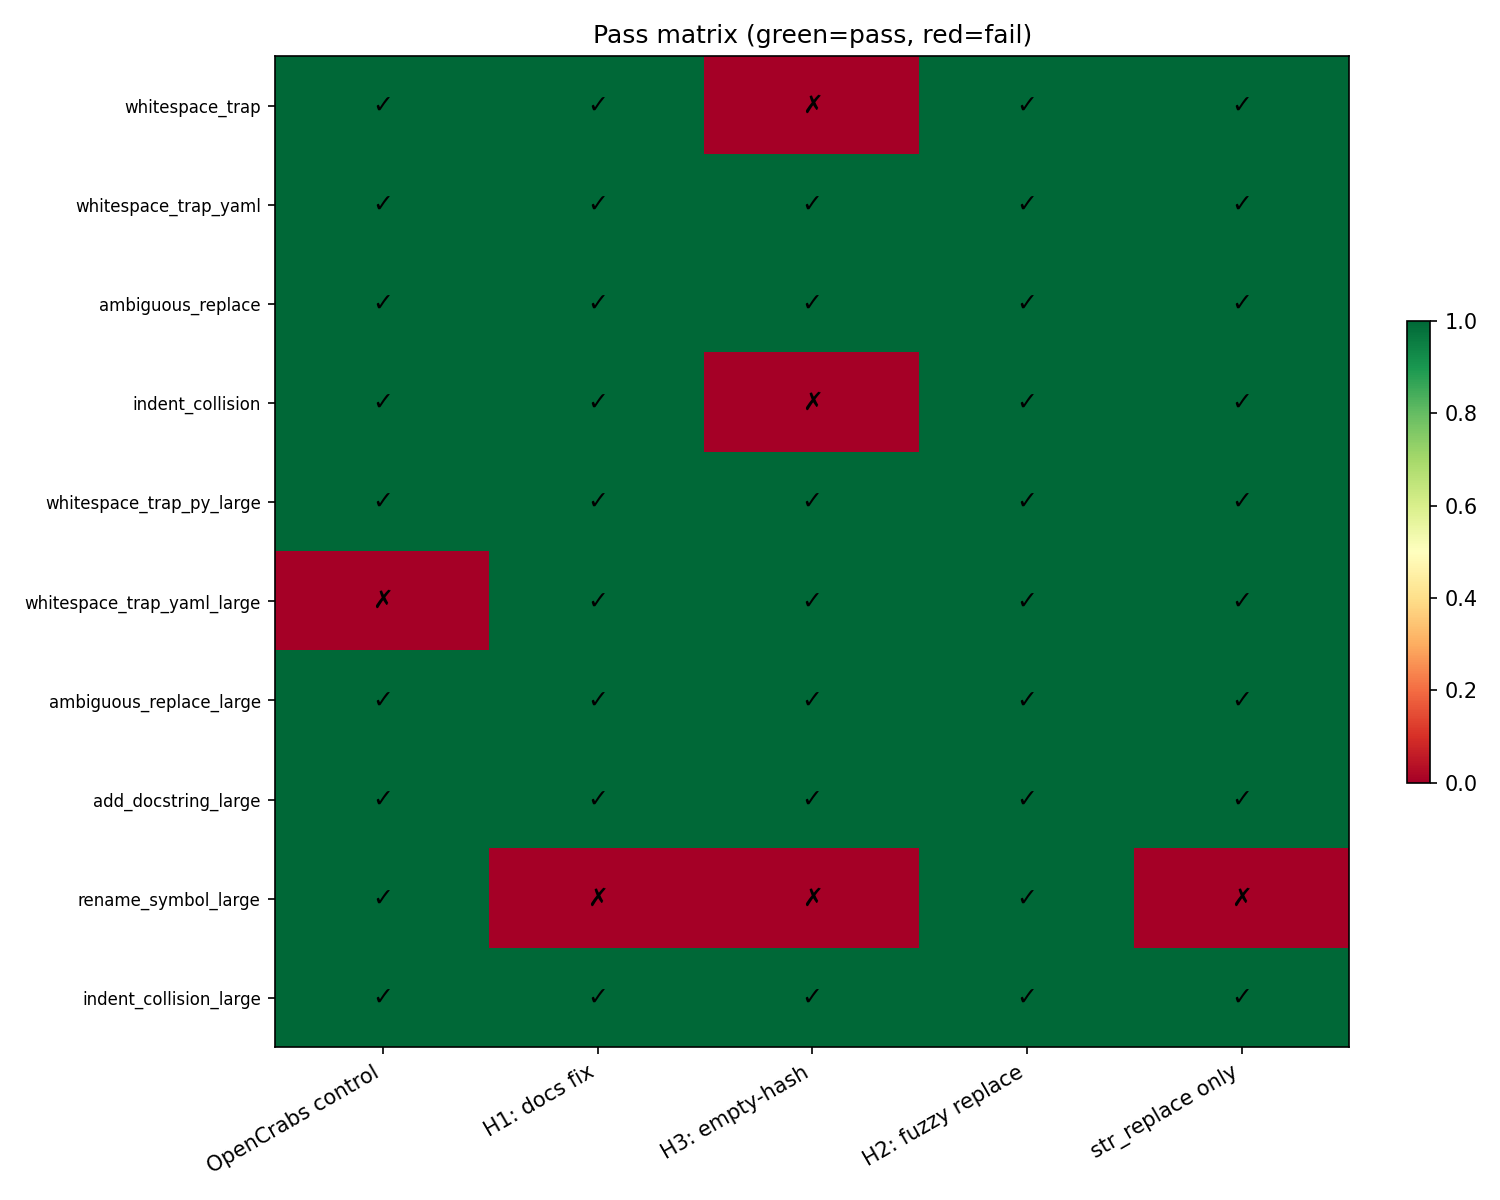

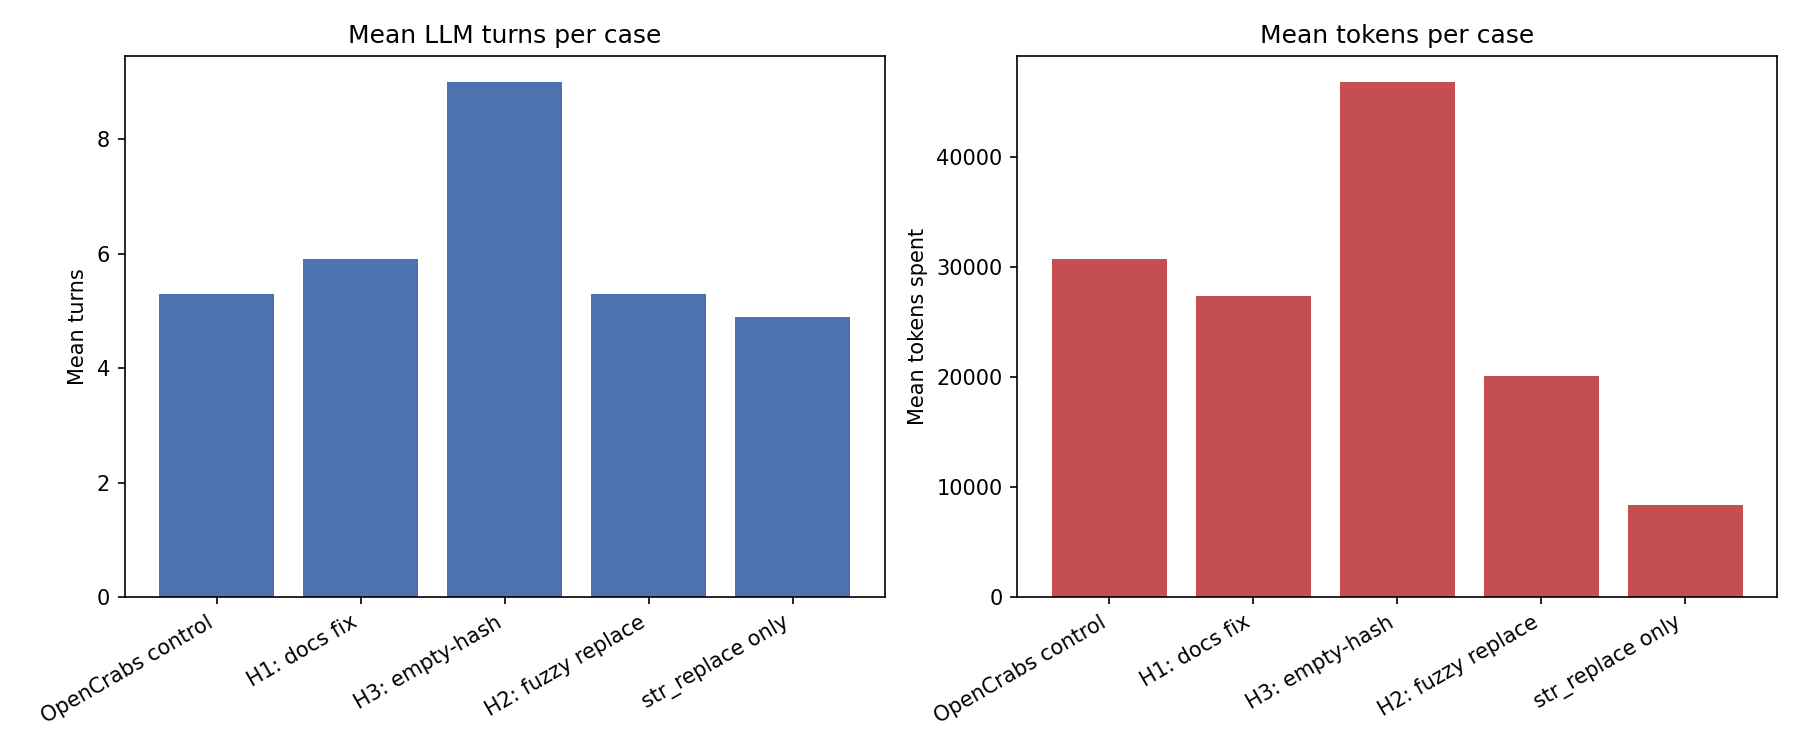

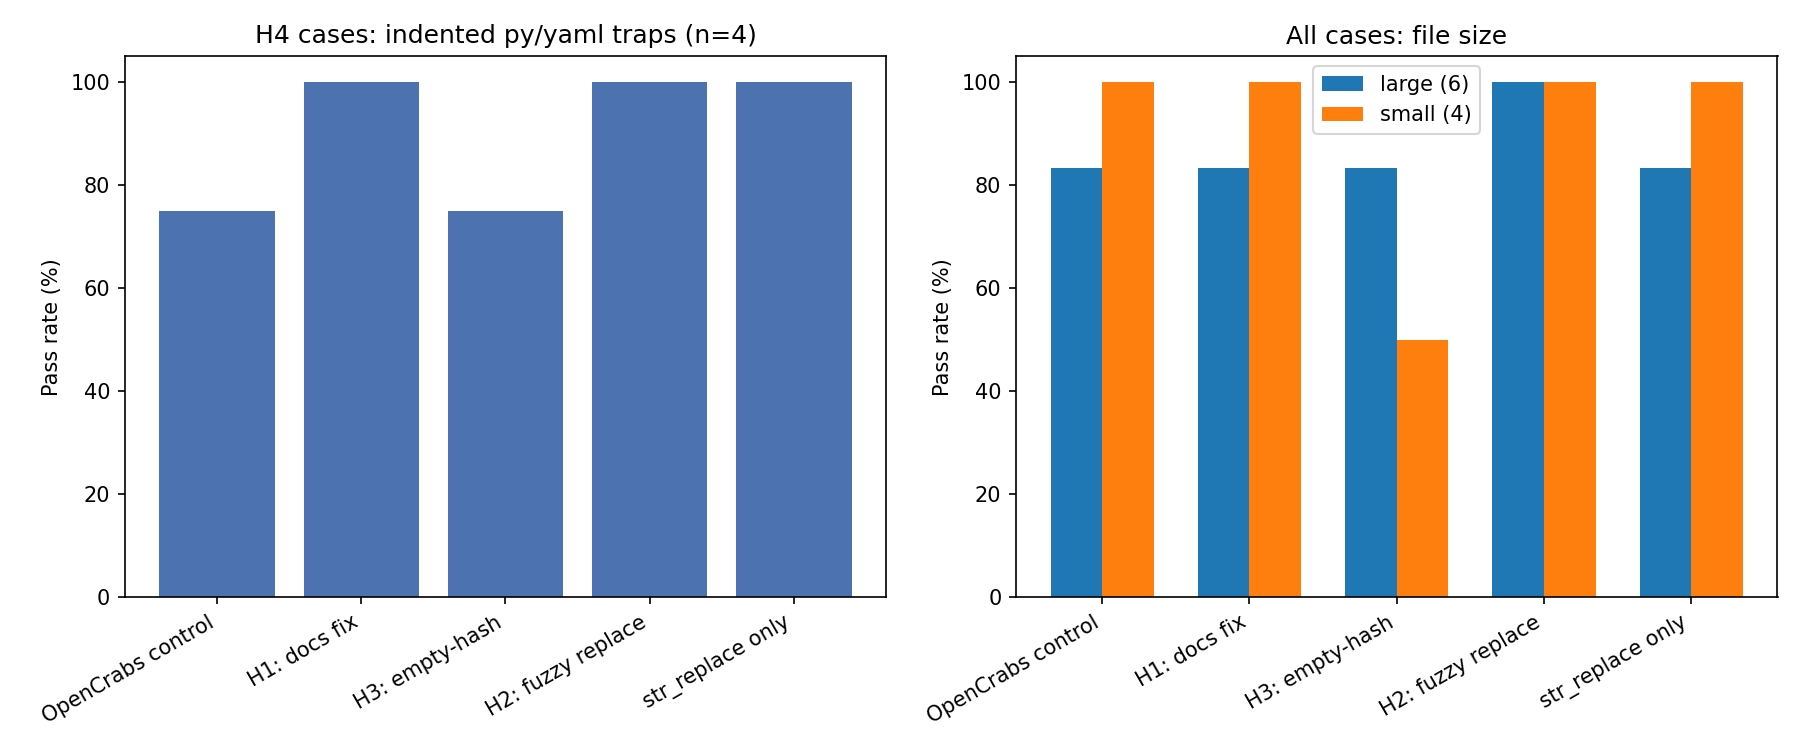

In [1]:
from pathlib import Path
import json, subprocess, sys
subprocess.check_call([sys.executable, 'docs/_build_report_viz.py'])
import pandas as pd
from IPython.display import Image, display
REPORT = Path('reports/2026-05-23T13-22-35.666225+00-00_local-r_matrix.json')
data = json.loads(REPORT.read_text())
rows = [{'variant': r['variant_id'].rsplit('/', 1)[0], 'case_name': r['case_name'],
         'passed': r['passed'], 'turns': r.get('turns', 0), 'tokens_spent': r.get('tokens_spent', 0)}
        for r in data['results']]
df = pd.DataFrame(rows)
labels = {'opencrabs_original': 'OpenCrabs control', 'opencrabs_h1_docs': 'H1: docs fix',
          'opencrabs_h3_collision': 'H3: empty-hash', 'opencrabs_h2_fuzzy': 'H2: fuzzy replace',
          'baseline': 'str_replace only'}
df['label'] = df['variant'].map(labels)
display(df.groupby('label').agg(pass_rate=('passed', 'mean'), turns=('turns', 'mean'),
                              tokens=('tokens_spent', 'mean')).round(2))
for f in ['pass_rate_by_variant.png', 'pass_matrix_heatmap.png',
          'efficiency_tokens_turns.png', 'h4_cases_and_file_size.png']:
    display(Image(filename=f'docs/figures/{f}'))
